# Data Cleaning & Validation

This project uses an ETL pipeline to clean, standardize, and validate mission records before loading them into the PostgreSQL data warehouse.

## 1. Column Name Standardization

All column names are converted to snake_case format to ensure consistency across the pipeline.

### Example

| Original Column  | Standardized Column |
| ---------------- | ------------------- |
| Launch Date      | launch_date         |
| Mission Phase    | mission_phase       |
| Cost USD Million | cost_usd_million    |

---

## 2. Missing Value Standardization

Common placeholder values representing missing data are converted to NULL.

The following values are treated as missing:

* `N/A`
* `NA`
* `None`
* `Unknown`
* `Not Applicable`
* Empty strings
* `NaN`

Leading and trailing whitespace is also removed from text fields.

---

## 3. Date Conversion

Date fields are converted to datetime format.

### Columns

* `launch_date`
* `end_date`

Invalid dates are converted to NULL using Pandas' `errors='coerce'` option.

---

## 4. Agency Founding Date Validation

Mission launch dates are validated against the founding year of the responsible space agency.

A mission cannot launch before the agency officially existed.

### Example

| Agency | Founded |
| ------ | ------- |
| NASA   | 1958    |
| ESA    | 1975    |
| SpaceX | 2002    |

Records violating this rule are removed from the dataset.

---

## 5. Mission Duration Standardization

Human-readable duration values are converted into a numeric field named:

`duration_days`

### Supported Formats

Examples include:

* `2 years`
* `6 months`
* `15 days`
* `12 hours`
* Mixed expressions such as:

  * `1 year 6 months`
  * `3 months 10 days`

### Conversion Factors

| Unit  | Days   |
| ----- | ------ |
| Year  | 365.25 |
| Month | 30.44  |
| Day   | 1      |
| Hour  | 1/24   |

Unrecognized duration values are converted to NULL.

---

## 6. Cost Standardization

Mission cost values are converted to numeric format.

Invalid cost values are converted to NULL.

The original column:

`cost_usd_million`

is converted to:

`cost_usd_billion`

using the transformation:

cost_usd_billion = cost_usd_million / 1000

This standardizes all cost values into billions of USD.

---

## 7. Categorical Value Validation

Several categorical fields are validated against predefined allowed values.

### Status

Allowed values:

* Success
* Failed
* Partial Success
* Ongoing
* Upcoming

### Mission Phase

Allowed values:

* Past
* Ongoing
* Future

### Crew Type

Allowed values:

* Crewed
* Uncrewed

### Data Returned

Allowed values:

* Yes
* No
* Partial
* NULL

Unexpected values are logged for review during ETL execution.

---

## 8. Data Quality Logging

The ETL process records validation metrics including:

* Rows removed during validation
* Failed duration parsing attempts
* Missing mission costs
* Unexpected categorical values
* Pipeline execution status

These logs provide traceability and support ongoing data quality monitoring.



# ETL Pipeline Overview

The ETL process is implemented through dedicated Python modules:

* `etl_load.py`
* `db.py`

## ETL Workflow

The pipeline performs the following steps:

1. Load the raw CSV dataset.
2. Clean and standardize all columns.
3. Validate dates, categorical values, and numeric fields.
4. Parse complex text fields such as mission duration and partner agencies.
5. Build dimension tables and fact tables.
6. Create bridge tables for many-to-many relationships.
7. Load the cleaned schema into PostgreSQL.
8. Apply indexes for analytical query performance.

---

# Database Design

The original dataset was provided as a flat file.

To improve analytical usability and reduce structural nulls, the data was transformed into a star-schema warehouse design.

## Schema Components

### Fact Table

* `fact_missions`

Contains measurable mission-level attributes such as:

* mission status
* duration
* cost
* mission category

### Dimension Tables

* `dim_date`
* `dim_agency`
* `dim_launch`
* `dim_mission_meta`

These tables isolate descriptive attributes and reduce redundancy.

### Bridge Tables

* `bridge_crew`
* `bridge_partners`

These tables resolve many-to-many relationships between missions, crew members, and partner agencies.

---

## Environment Setup

This section imports the required libraries, configures the notebook environment, and initializes logging and database utilities used throughout the project.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

from src.logger import setup_logging, get_logger
from src.db import load_missions_with_meta, health_check
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



In [2]:
setup_logging()
log = get_logger(__name__)

log.info("Starting data cleaning notebook")

05:17:46  INFO      Logging initialised — file: F:\projects\space_mission_analysis\notebooks\logs\space_missions.log
05:17:46  INFO      Starting data cleaning notebook


## Database Validation

Before beginning the analysis, a database health check is performed to verify that all dimension, fact, and bridge tables were loaded successfully into PostgreSQL.

In [3]:
setup_logging()
log = get_logger(__name__)

health_check()


05:17:58  INFO      ── Database Health Check ─────────────────────
05:17:58  INFO      Database engine initialised — localhost:5433/space_missions
05:17:59  INFO        dim_date                    7,648 rows
05:17:59  INFO        dim_agency                     11 rows
05:17:59  INFO        dim_launch                    121 rows
05:17:59  INFO        dim_mission_meta            7,007 rows
05:17:59  INFO        fact_missions               7,007 rows
05:17:59  INFO        bridge_crew                 7,780 rows
05:17:59  INFO        bridge_partners             2,861 rows
05:17:59  INFO      Health check passed — all tables populated.
05:17:59  INFO      ──────────────────────────────────────────────


## Load raw Dataset

The  dataset is loaded from PostgreSQL using the custom database helper functions defined in `db.py`.

The loaded dataset combines:

- fact tables
- dimension tables
- mission metadata

into a single analytical dataframe suitable for validation and exploratory analysis.

In [4]:
df = load_missions_with_meta()
df.shape

05:18:01  INFO      load_missions_with_meta → 7,007 rows


(7007, 28)

## Preview Dataset Structure

The first few rows are inspected to verify that the schema loaded correctly and to understand the structure of the analytical dataset.

In [30]:
df.head()

,Mission_ID,Mission_Name,Agency,Country_Region,Agency_Type,Program_Type,Mission_Category,Sub_Category,Launch_Date,End_Date,...,Crew_Members,Destination,Objective,Key_Achievement,Cost_USD_Million,Partner_Agencies,Data_Returned,Failure_Reason,Mission_Outcome_Detail,Reference_URL
0,NA-00001,Explorer 1,NASA,USA,Government,Technology Demo,Mercury,Orbiter,1976-01-12,1987-02-18,...,NaN,Mercury,Black hole imaging and stellar cataloguing,Debris impact damaged solar panels,7708.6,NaN,Partial,Debris impact damaged solar panels,Exceeded planned science return by 3x,https://www.nasa.gov/mission/explorer-1
1,NA-00002,Pioneer 1,NASA,USA,Government,Human Spaceflight,Saturn,Flyby,1977-05-01,1984-07-15,...,NaN,Saturn,Orbital mechanics experiment for future missions,Detected water ice at target location,11802.2,SpaceX,Yes,NaN,Detected organic molecules at surface,https://www.nasa.gov/mission/pioneer-1
2,NA-00003,Mercury-Redstone 1,NASA,USA,Government,Sounding Rocket,Earth Observation,Climate Study,1966-01-13,1969-12-13,...,"Pilot, PS2",Earth Observation,Gamma-ray burst detection and cataloguing,NaN,7836.7,NaN,Yes,NaN,Planned - objectives to be confirmed post-launch,https://www.nasa.gov/mission/mercury-redstone-1
3,NA-00004,Freedom 7,NASA,USA,Government,Satellite,Mercury,Flyby,1987-07-06,1989-03-19,...,NaN,Mercury,Earth observation for disaster management,Demonstrated reusable rocket landing,10659.5,NaN,Partial,NaN,Failed to achieve orbit due to launch vehicle ...,https://www.nasa.gov/mission/freedom-7
4,NA-00005,Friendship 7,NASA,USA,Government,Commercial,Telescope,Radio,2012-09-09,NaN,...,NaN,Telescope,Human lunar landing mission support,Discovered new geological features,4385.5,JAXA,Yes,NaN,Detected organic molecules at surface,https://www.nasa.gov/mission/friendship-7


## Initial Data Inspection

The dataset structure is inspected to evaluate:

- data types
- column completeness
- memory usage
- general schema integrity

Special attention is given to numerical and datetime fields that may require additional validation.

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10500 entries, 0 to 10499
Data columns (total 26 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Mission_ID              10500 non-null  object 
 1   Mission_Name            10500 non-null  object 
 2   Agency                  10500 non-null  object 
 3   Country_Region          10500 non-null  object 
 4   Agency_Type             10500 non-null  object 
 5   Program_Type            10500 non-null  object 
 6   Mission_Category        10500 non-null  object 
 7   Sub_Category            10500 non-null  object 
 8   Launch_Date             10500 non-null  object 
 9   End_Date                5796 non-null   object 
 10  Duration                10266 non-null  object 
 11  Launch_Vehicle          10500 non-null  object 
 12  Launch_Site             10500 non-null  object 
 13  Status                  10500 non-null  object 
 14  Mission_Phase           10500 non-null

In [35]:
df.columns = (
        df.columns
        .str.strip()
        .str.lower()
        .str.replace(" ", "_", regex=False)
    )

## Descriptive Statistics

Descriptive statistics are reviewed to identify:

- unexpected distributions
- unusual categorical frequencies
- possible data quality issues
- early signs of skewness or outliers

Because many columns are categorical, the output primarily highlights the most common values across the dataset.

In [32]:
df.describe(include='all')

,Mission_ID,Mission_Name,Agency,Country_Region,Agency_Type,Program_Type,Mission_Category,Sub_Category,Launch_Date,End_Date,...,Crew_Members,Destination,Objective,Key_Achievement,Cost_USD_Million,Partner_Agencies,Data_Returned,Failure_Reason,Mission_Outcome_Detail,Reference_URL
count,10500,10500,10500,10500,10500,10500,10500,10500,10500,5796,...,2637,10500,10500,10179,10500.000000,4336,8940,1161,10500,10500
unique,10500,10477,27,10,2,7,19,66,8496,5067,...,1792,19,25,34,NaN,10,3,12,25,10497
top,NA-00001,Crew-9,NASA,USA,Government,Robotic,Mercury,Flyby,2023-01-04,2022-11-11,...,"MS1, Commander",Mercury,Asteroid composition and deflection study,Planned - objectives to be confirmed post-launch,NaN,NASA,Partial,Reduced data return,First images returned from target destination,https://www.nasa.gov/mission/nisar
freq,1,2,973,2796,8689,1554,597,1196,8,5,...,20,597,459,1871,NaN,1702,3094,194,470,2
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,7383.777229,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,4314.648281,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,5.100000,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,3662.100000,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,7398.300000,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,11064.025000,NaN,NaN,NaN,NaN,NaN


## Numerical Validation

The `cost_usd_million` and `duration_days` columns are analyzed after conversion to numeric types.

Initial inspection shows:

- the mean and median values are relatively close
- no extreme outliers are immediately visible
- the overall distributions appear reasonable during the cleaning phase

Further distribution analysis will be performed during exploratory analysis.

In [ ]:
df['cost_usd_billion'] = pd.to_numeric(df['cost_usd_billion'], errors='coerce')
df['duration_days'] = pd.to_numeric(df['duration_days'], errors='coerce')
df[["cost_usd_billion", "duration_days"]].describe(
    percentiles=[.25, .5, .75, .90, .95, .99]
).round(2)

,cost_usd_billion,duration_days
count,7007.00,2906.00
mean,7.37,2318.43
std,4.34,1621.01
min,0.01,3.00
25%,3.63,913.12
50%,7.36,2045.40
75%,11.07,3615.97
90%,13.40,4766.51
95%,14.23,5223.07
99%,14.84,5586.49


## Duplicate Mission Name Analysis

Mission names are checked for duplication to determine whether duplicate records exist within the dataset.

In [9]:
df['mission_name'].duplicated().sum()

np.int64(7)

## Duplicate ID Validation

Mission identifiers are validated to confirm that each mission record contains a unique primary key.

In [10]:
df['mission_id'].duplicated().sum()

np.int64(0)

## Investigating Duplicate Mission Names

Duplicate mission names are inspected in detail.

The review shows that duplicated mission names belong to different agencies, meaning the records represent separate missions rather than duplicated observations.

As a result, these records are retained.

In [11]:
d= df[df['mission_name'].duplicated(keep=False)].sort_values('mission_name')
d.head(10)

,mission_id,mission_name,program_type,mission_category,sub_category,destination,status,mission_phase,crew_type,data_returned,...,launch_date,launch_year,launch_decade,end_date,end_year,end_decade,objective,key_achievement,mission_outcome_detail,reference_url
186,NA-00116,CRS-10,Telescope,Technology Demo,Debris Removal,Technology Demo,Success,Past,Uncrewed,Partial,...,1969-05-04,1969,1960s,1974-10-04,1974.0,1970s,Interplanetary navigation technology test,First images returned from target destination,Achieved orbit insertion on first attempt,https://www.nasa.gov/mission/crs-10
1650,SP-00838,CRS-10,Satellite,SmallSat,IoT Connectivity,SmallSat,Success,Past,Uncrewed,Yes,...,2002-09-29,2002,2000s,2005-05-26,2005.0,2000s,Heliosphere boundary exploration,Demonstrated reusable rocket landing,Broke distance record for agency,https://www.spacex.com/missions/crs-10
2934,NA-00117,CRS-15,Human Spaceflight,SmallSat,Science,SmallSat,Partial Success,Past,Uncrewed,No,...,2015-10-23,2015,2010s,2022-06-17,2022.0,2020s,Gamma-ray burst detection and cataloguing,Detected organic molecules at surface,Broke distance record for agency,https://www.nasa.gov/mission/crs-15
3020,SP-00843,CRS-15,Robotic,Sun/Solar,Solar Observer,Sun/Solar,Success,Past,Uncrewed,Partial,...,2016-08-28,2016,2010s,2023-03-26,2023.0,2020s,Neptune and Uranus atmospheric study flyby,Deployed constellation of satellites,Demonstrated reusable rocket landing,https://www.spacex.com/missions/crs-15
1702,SP-00870,Crew-10,Sounding Rocket,Mars,Sample Return,Mars,Ongoing,Past,Uncrewed,No,...,2003-04-16,2003,2000s,None,NaN,None,High-resolution Earth surface mapping,Discovered new geological features,Extended mission beyond original timeline,https://www.spacex.com/missions/crew-10
2151,NA-00113,Crew-10,Commercial,Asteroid,Rendezvous,Asteroid,Ongoing,Past,Crewed,No,...,2008-01-04,2008,2000s,None,NaN,None,Solar wind and coronal mass ejection monitoring,Successfully tested new propulsion system,Successfully deployed all planned instruments,https://www.nasa.gov/mission/crew-10
36,NA-00111,Crew-8,Technology Demo,Jupiter,Flyby,Jupiter,Success,Past,Uncrewed,Partial,...,1960-11-08,1960,1960s,1974-03-16,1974.0,1970s,Technology demonstration for future deep space...,First images returned from target destination,Communication lost after initial deployment,https://www.nasa.gov/mission/crew-8
2200,SP-00868,Crew-8,Satellite,Telescope,Gamma Ray,Telescope,Partial Success,Past,Uncrewed,No,...,2008-05-29,2008,2000s,2018-02-03,2018.0,2010s,Asteroid composition and deflection study,Failed to achieve orbit due to launch vehicle ...,Communication lost after initial deployment,https://www.spacex.com/missions/crew-8
1365,NA-00075,GRACE,Sounding Rocket,Sun/Solar,Parker-type,Sun/Solar,Success,Past,Uncrewed,Yes,...,1999-03-27,1999,1990s,2000-05-28,2000.0,2000s,Heliosphere boundary exploration,Extended mission beyond original timeline,Successfully tested new propulsion system,https://www.nasa.gov/mission/grace
3205,DL-01074,GRACE,Satellite,Moon,Orbiter,Moon,Failed,Past,Uncrewed,Partial,...,2018-06-27,2018,2010s,2023-05-31,2023.0,2020s,Lunar surface exploration and soil sample coll...,Guidance system malfunction,Historic first for agency and country,https://www.dlr.de/mission/grace


## Missing Value Assessment

Null values are evaluated to distinguish:

- true missing data
- structural nulls caused by the flat-file design

Examples of structural nulls include:

- `failure_reason` for successful missions
- `end_date` for ongoing missions
- `key_achievement` for failed missions

These values contain meaningful business logic and are therefore preserved.

In [12]:
null_counts = df.isnull().sum()
null_pct = (null_counts / len(df)*100).round(2)
null_summary = pd.DataFrame({'null_count': null_counts, 'null_pct': null_pct}).query('null_count > 0').sort_values('null_pct', ascending=False)
print(null_summary) 

                 null_count  null_pct
failure_reason         6363     90.81
duration_days          4101     58.53
end_date               3936     56.17
end_decade             3936     56.17
end_year               3936     56.17
data_returned          1438     20.52
key_achievement         164      2.34


## Missing Value Visualization

A visual summary of missing values is created to identify patterns and confirm that the null values primarily reflect structural characteristics rather than data quality failures.

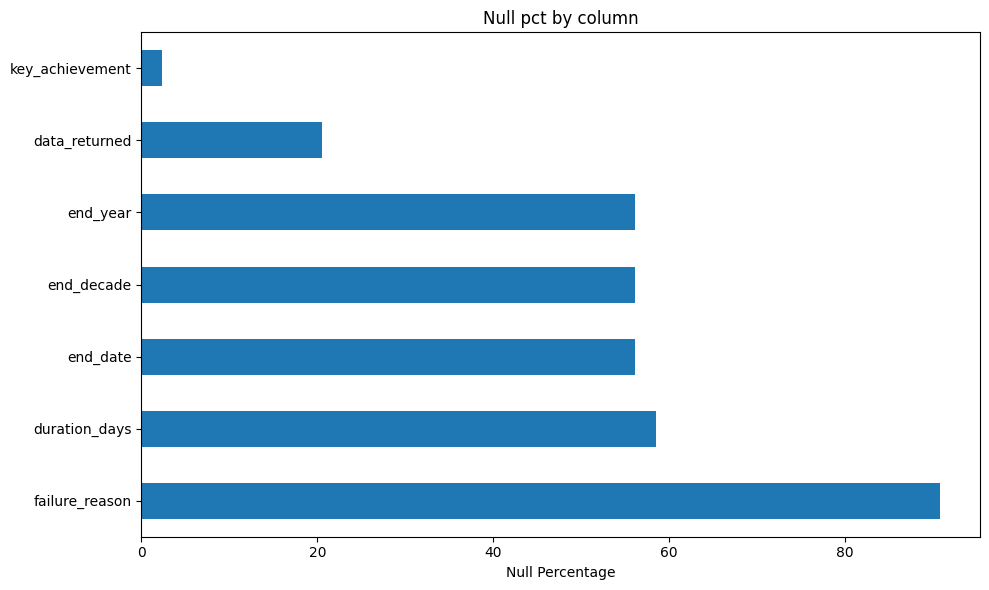

In [13]:
fig, ax = plt.subplots(figsize=(10,6))
null_summary['null_pct'].plot(kind = 'barh', ax=ax)
ax.set_title('Null pct by column')
ax.set_xlabel('Null Percentage')
fig.tight_layout()
plt.show()

## Categorical Consistency Validation

Categorical columns are reviewed using value counts to identify:

- spelling inconsistencies
- formatting issues
- unexpected category labels

The inspection confirms that the categorical fields are standardized and internally consistent.

In [14]:
cat_cols = ["status", "mission_phase", "crew_type", "agency_type",
            "program_type", "mission_category", "data_returned"]

for col in cat_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(dropna=False))


--- status ---
status
Ongoing            2498
Success            2263
Upcoming           1438
Failed              495
Partial Success     313
Name: count, dtype: int64

--- mission_phase ---
mission_phase
Past       3629
Ongoing    1940
Future     1438
Name: count, dtype: int64

--- crew_type ---
crew_type
Uncrewed    5270
Crewed      1737
Name: count, dtype: int64

--- agency_type ---
agency_type
Government    5942
Private       1065
Name: count, dtype: int64

--- program_type ---
program_type
Robotic              1036
Commercial           1022
Satellite            1021
Sounding Rocket       995
Telescope             981
Technology Demo       976
Human Spaceflight     976
Name: count, dtype: int64

--- mission_category ---
mission_category
Mercury                    399
Mars                       393
SmallSat                   391
Deep Space                 385
Crewed Spaceflight         383
Jupiter                    383
Telescope                  378
CubeSat                    378


## Numeric Type Conversion

The `cost_usd_billion` column is explicitly converted to a numeric type to ensure compatibility with statistical analysis, machine learning workflows, and visualization libraries.

In [15]:
df['cost_usd_billion'] = pd.to_numeric(df['cost_usd_billion'], errors='coerce')
df['duration_days'] = pd.to_numeric(df['duration_days'], errors='coerce')

## Distribution Review

The distributions of mission cost and duration are visualized using histograms.

### Findings

- Mission duration appears reasonably distributed.
- Mission cost displays a potentially unusual pattern.

This observation will be investigated further during the Exploratory Data Analysis stage.

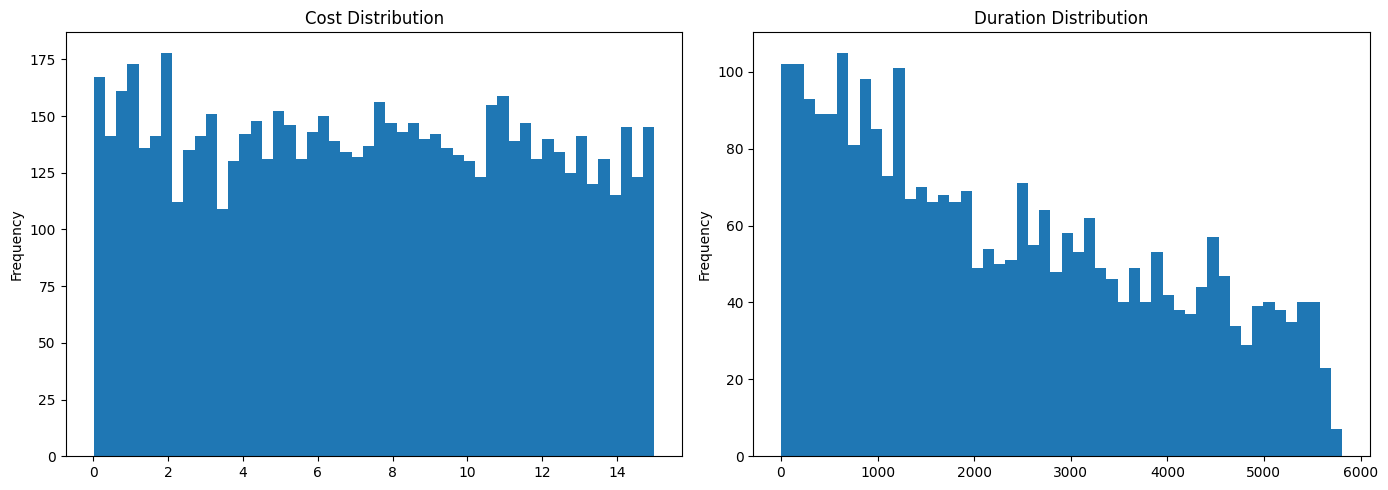

In [16]:
fig,axes = plt.subplots(1,2, figsize=(14,5))
df['cost_usd_billion'].plot(kind='hist', bins=50, ax=axes[0])
axes[0].set_title('Cost Distribution')
df['duration_days'].plot(kind='hist', bins=50, ax=axes[1])
axes[1].set_title('Duration Distribution')
plt.tight_layout()
plt.show()

## Temporal Validation

Date fields are validated for chronological consistency.

### Findings

A subset of missions contains an `end_date` earlier than the corresponding `launch_date`.

These observations violate temporal logic and are deleted in etl_load

In [17]:
df[df['end_date'].notna() & (df['end_date'] < df['launch_date'])]

,mission_id,mission_name,program_type,mission_category,sub_category,destination,status,mission_phase,crew_type,data_returned,...,launch_date,launch_year,launch_decade,end_date,end_year,end_decade,objective,key_achievement,mission_outcome_detail,reference_url
61,NA-05393,NASA Moon Mission 5393,Human Spaceflight,Moon,Orbiter,Moon,Failed,Past,Uncrewed,Yes,...,1962-07-30,1962,1960s,1962-05-30,1962.0,1960s,Lunar surface exploration and soil sample coll...,Software error during critical maneuver,Broke distance record for agency,https://www.nasa.gov/mission/nasa-moon-mission...
83,NA-02261,NASA CubeSat Mission 2261,Commercial,CubeSat,12U CubeSat,CubeSat,Partial Success,Past,Uncrewed,Partial,...,1963-06-22,1963,1960s,1963-01-05,1963.0,1960s,Reusable launch vehicle technology demonstration,Planned - objectives to be confirmed post-launch,Successfully deployed all planned instruments,https://www.nasa.gov/mission/nasa-cubesat-miss...
105,NA-04854,NASA Moon Mission 4854,Satellite,Moon,Sample Return,Moon,Failed,Past,Uncrewed,Partial,...,1964-10-09,1964,1960s,1964-07-26,1964.0,1960s,Mars sample return mission support,Launch vehicle upper stage malfunction,Confirmed presence of subsurface water,https://www.nasa.gov/mission/nasa-moon-mission...
173,CN-02031,CNES Crewed Spaceflight Mission 2031,Robotic,Crewed Spaceflight,Moon Mission,Crewed Spaceflight,Failed,Past,Uncrewed,Yes,...,1968-10-13,1968,1960s,1968-05-28,1968.0,1960s,Solar wind and coronal mass ejection monitoring,None,Broke distance record for agency,https://cnes.fr/mission/cnes-crewed-spacefligh...
243,CN-03106,CNES Technology Demo Mission 3106,Human Spaceflight,Technology Demo,Debris Removal,Technology Demo,Failed,Past,Uncrewed,No,...,1971-09-11,1971,1970s,1971-05-08,1971.0,1970s,Heliosphere boundary exploration,None,Completed all primary mission objectives,https://cnes.fr/mission/cnes-technology-demo-m...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4408,SP-05299,SpaceX Crewed Spaceflight Mission 5299,Commercial,Crewed Spaceflight,Moon Mission,Crewed Spaceflight,Success,Past,Uncrewed,Partial,...,2022-12-20,2022,2020s,2022-06-26,2022.0,2020s,Heliosphere boundary exploration,Failed to achieve orbit due to launch vehicle ...,Mission ongoing - data collection in progress,https://www.spacex.com/missions/spacex-crewed-...
4413,JA-09428,JAXA Saturn Mission 9428,Robotic,Saturn,Orbiter,Saturn,Success,Past,Uncrewed,No,...,2022-12-24,2022,2020s,2022-04-03,2022.0,2020s,High-resolution Earth surface mapping,Confirmed presence of subsurface water,Planned - objectives to be confirmed post-launch,https://www.jaxa.jp/missions/jaxa-saturn-missi...
4414,SP-03185,SpaceX Moon Mission 3185,Commercial,Moon,Flyby,Moon,Failed,Past,Crewed,Partial,...,2022-12-27,2022,2020s,2022-08-06,2022.0,2020s,High-resolution Earth surface mapping,Launch vehicle upper stage malfunction,Achieved orbit insertion on first attempt,https://www.spacex.com/missions/spacex-moon-mi...
4416,SP-06792,SpaceX CubeSat Mission 6792,Human Spaceflight,CubeSat,16U CubeSat,CubeSat,Success,Past,Crewed,No,...,2022-12-28,2022,2020s,2022-08-22,2022.0,2020s,Commercial crew certification flight,Planned - objectives to be confirmed post-launch,Extended mission beyond original timeline,https://www.spacex.com/missions/spacex-cubesat...
